# PREPROCESSING

In [26]:
import json
import pandas as pd
from feature_extractor import FeatureExtractor
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import numpy as np
from random import shuffle
import os

In [ ]:
def to_single_message_format(gamefile):
    messages = []
    with open(gamefile) as inh:
        for ln in inh:
            conversation = json.loads(ln)
            for msg, sender_label, receiver_label,  speaker, receiver, abs_index, rel_index, season, year, game_score, game_score_delta in zip(
                conversation['messages'], conversation['sender_labels'], conversation['receiver_labels'], 
                conversation['speakers'], conversation['receivers'], 
                conversation['absolute_message_index'], conversation['relative_message_index'], 
                conversation['seasons'], conversation['years'], conversation['game_score'], 
                conversation['game_score_delta']):
                    # if receiver_label != "NOANNOTATION": #to remove the noise
                messages.append({
                    'message': msg,
                    'receiver_annotation': receiver_label,
                    'sender_annotation': sender_label,
                    'speaker': speaker,
                    'receiver': receiver,
                    'absolute_message_index': abs_index,
                    'relative_message_index': rel_index,
                    'season': season,
                    'year': int(year),
                    'game_score': int(game_score),
                    'game_score_delta': int(game_score_delta),
                    'game_id': conversation['game_id']
                })
    shuffle(messages)
    return messages

In [28]:
def write_single_messages(messages, outfile):
    with open(outfile, "w") as outh:
        for msg in messages:
            outh.write(json.dumps(msg)+'\n')

In [29]:
ROOT = "data"
write_single_messages(to_single_message_format(os.path.join(ROOT, 'validation.jsonl')) , os.path.join(ROOT, 'validation_sm.jsonl'))
write_single_messages(to_single_message_format(os.path.join(ROOT, 'train.jsonl')) , os.path.join(ROOT, 'train_sm.jsonl'))
write_single_messages(to_single_message_format(os.path.join(ROOT, 'test.jsonl')) ,  os.path.join(ROOT, 'test_sm.jsonl'))

# FEATURE EXTRACTION

In [ ]:
def read_jsonl(file_path):
    """Read messages and additional fields from a JSONL file."""
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data

def extract_features_from_messages(data):
    """Extract features from a list of messages using FeatureExtractor and include additional fields."""
    feature_extractor = FeatureExtractor()
    features_list = []
    for entry in data:
        # Extract features from the message
        features = feature_extractor.extract_features(entry['message'])
        # Include additional fields as features
        features.update({
            'receiver_annotation': entry['receiver_annotation'],
            'sender_annotation': entry['sender_annotation'],
            'speaker': entry['speaker'],
            'receiver': entry['receiver'],
            'absolute_message_index': entry['absolute_message_index'],
            'relative_message_index': entry['relative_message_index'],
            'season': entry['season'],
            'year': entry['year'],
            'game_score': entry['game_score'],
            'game_score_delta': entry['game_score_delta'],
            'game_id': entry['game_id']
        })
        features_list.append(features)
    return features_list

def create_dataframe(features_list):
    """Create a pandas DataFrame from a list of feature dictionaries."""
    return pd.DataFrame(features_list)

def process_jsonl_to_dataframe(file_path):
    """Process a JSONL file to a pandas DataFrame with extracted features and additional fields."""
    data = read_jsonl(file_path)
    features_list = extract_features_from_messages(data)
    df = create_dataframe(features_list)
    return df

# File paths for train, validation, and test sets
train_file_path = 'data/train_sm.jsonl'
val_file_path = 'data/validation_sm.jsonl'
test_file_path = 'data/test_sm.jsonl'

# Create DataFrames for each dataset
train_df = process_jsonl_to_dataframe(train_file_path)
val_df = process_jsonl_to_dataframe(val_file_path)
test_df = process_jsonl_to_dataframe(test_file_path)

NameError: name 'FeatureExtractor' is not defined

In [ ]:
train_df.head(10)

,sentiment_polarity,avg_sentence_length,avg_word_length,type_token_ratio,function_word_count,pronoun_usage,third_person_pronoun_count,flesch_reading_ease,flesch_kincaid_grade,comma_count,...,sender_annotation,speaker,receiver,absolute_message_index,relative_message_index,season,year,game_score,game_score_delta,game_id
0,0.333333,12.0,4.166667,0.875000,3,3,3,93.14,3.3,1,...,True,russia,england,1189,60,Spring,1905,5,0,1
1,0.000000,6.5,4.076923,0.923077,1,1,0,92.12,3.6,1,...,True,france,germany,118,2,Spring,1901,3,0,7
2,0.000000,9.0,3.111111,1.000000,2,1,0,104.64,0.9,1,...,True,england,germany,807,149,Fall,1908,10,3,10
3,0.000000,13.0,4.076923,0.846154,3,0,0,83.66,4.8,1,...,True,england,germany,2106,254,Fall,1904,6,-1,2
4,-0.065278,17.0,4.152941,0.682353,14,11,1,62.68,8.7,3,...,True,italy,turkey,1542,63,Fall,1906,6,2,3
5,0.025000,9.5,3.947368,0.947368,2,1,0,87.21,3.5,0,...,True,austria,italy,2706,614,Spring,1905,8,2,2
6,0.200000,8.0,3.250000,1.000000,3,1,0,105.66,0.5,0,...,True,england,russia,647,70,Fall,1902,5,0,3
7,0.150000,30.5,3.901639,0.786885,12,2,0,66.41,11.5,4,...,False,austria,italy,558,44,Winter,1903,7,3,10
8,0.258333,14.0,4.119048,0.809524,7,7,0,82.65,5.2,1,...,True,england,france,322,81,Winter,1901,4,-1,1
9,0.188889,22.0,3.727273,1.000000,2,1,0,73.51,8.7,2,...,True,italy,austria,20,5,Spring,1901,3,0,2


In [ ]:
# Feature Selection using SelectKBest on TRAINING data
X_train = train_df.drop('sender_annotation', axis=1)
y_train = train_df['sender_annotation']
X_val = val_df.drop('sender_annotation', axis=1)
y_val = val_df['sender_annotation']
X_test = test_df.drop('sender_annotation', axis=1)
y_test = test_df['sender_annotation']

# Encode categorical features for all datasets
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns - crucial step to ensure consistent feature sets across train, val, and test
common_cols = list(set(X_train_encoded.columns) & set(X_val_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_cols].fillna(0) # Fill NaN if any after alignment
X_val_encoded = X_val_encoded[common_cols].fillna(0)
X_test_encoded = X_test_encoded[common_cols].fillna(0)

# LR

In [ ]:
def train_and_evaluate_model(k, X_train_encoded, y_train, X_val_encoded, y_val, X_test_encoded, y_test):
    """
    Selects top k features, trains a Logistic Regression model with class weights,
    and evaluates it on validation and test sets.

    Args:
        k (int or 'all'): Number of top features to select.
        X_train_encoded (pd.DataFrame): Encoded training features.
        y_train (pd.Series): Training labels.
        X_val_encoded (pd.DataFrame): Encoded validation features.
        y_val (pd.Series): Validation labels.
        X_test_encoded (pd.DataFrame): Encoded test features.
        y_test (pd.Series): Test labels.

    Returns:
        tuple: Trained Logistic Regression model and selected feature names.
    """
    # --- Feature Selection with Best k ---
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train_encoded, y_train)
    X_val_selected = selector.transform(X_val_encoded)
    X_test_selected = selector.transform(X_test_encoded)

    # Convert selected features to DataFrames (for better readability later)
    selected_feature_names = X_train_encoded.columns[selector.get_support(indices=True)]
    X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
    X_val_selected_df = pd.DataFrame(X_val_selected, columns=selected_feature_names)
    X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

    # --- Train Logistic Regression Model ---
    logreg_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    logreg_model.fit(X_train_selected, y_train)

    # --- Evaluate on Validation Set ---
    y_val_pred = logreg_model.predict(X_val_selected)
    print("\n--- Validation Set Classification Report ---")
    print(classification_report(y_val, y_val_pred))

    # --- Evaluate on Test Set ---
    y_test_pred = logreg_model.predict(X_test_selected)
    print("\n--- Test Set Classification Report ---")
    print(classification_report(y_test, y_test_pred))

    return logreg_model, selected_feature_names

In [ ]:
X_train_encoded.shape

(13132, 44)

In [ ]:
def train_and_evaluate_model_all_features(X_train_encoded, y_train, X_val_encoded, y_val, X_test_encoded, y_test):
    """
    Trains a Logistic Regression model with class weights using all features
    and evaluates it on validation and test sets.

    Args:
        X_train_encoded (pd.DataFrame): Encoded training features.
        y_train (pd.Series): Training labels.
        X_val_encoded (pd.DataFrame): Encoded validation features.
        y_val (pd.Series): Validation labels.
        X_test_encoded (pd.DataFrame): Encoded test features.
        y_test (pd.Series): Test labels.

    Returns:
        tuple: Trained Logistic Regression model and feature names (all features).
    """

    # --- Train Logistic Regression Model ---
    logreg_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    logreg_model.fit(X_train_encoded, y_train)

    # --- Evaluate on Validation Set ---
    y_val_pred = logreg_model.predict(X_val_encoded)
    print("\n--- Validation Set Classification Report (All Features) ---")
    print(classification_report(y_val, y_val_pred))\

    # --- Evaluate on Test Set ---
    y_test_pred = logreg_model.predict(X_test_encoded)
    print("\n--- Test Set Classification Report (All Features) ---")
    print(classification_report(y_test, y_test_pred))

    return logreg_model, X_train_encoded.columns.tolist() # Return all feature names

In [ ]:
# Call the function to train and evaluate the model
logreg_model, selected_feature_names = train_and_evaluate_model_all_features(
     X_train_encoded, y_train, X_val_encoded, y_val, X_test_encoded, y_test
)

print("\n--- Selected Features (k={}) ---".format(best_k))
print(selected_feature_names)


--- Validation Set Classification Report (All Features) ---
              precision    recall  f1-score   support

       False       0.09      0.39      0.15        56
        True       0.97      0.84      0.90      1360

    accuracy                           0.82      1416
   macro avg       0.53      0.61      0.52      1416
weighted avg       0.94      0.82      0.87      1416


--- Test Set Classification Report (All Features) ---
              precision    recall  f1-score   support

       False       0.15      0.63      0.24       240
        True       0.95      0.64      0.77      2501

    accuracy                           0.64      2741
   macro avg       0.55      0.64      0.50      2741
weighted avg       0.88      0.64      0.72      2741


--- Selected Features (k=5) ---
['third_person_pronoun_count', 'absolute_message_index', 'relative_message_index', 'game_id', 'formality_score', 'receiver_france', 'sentiment_polarity', 'comparisons', 'temporal_other', 'type_toke

c:\Users\Rishi\Desktop\NLP-Project\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# EMBEDDINGS

In [1]:
!pip install -r requirements.txt

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
  Using cached torch-2.1.0-cp310-cp310-win_amd64.whl.metadata (24 kB)
  Using cached pandas-2.2.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.6.1-cp310-cp310-win_amd64.whl.metadata (15 kB)
  Using cached textstat-0.7.5-py3-none-any.whl.metadata (15 kB)
  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.12-cp310-cp310-win_amd64.whl.metadata (2.2 kB)
  Using cached cymem-2.0.11-cp310-cp310-win_amd64.whl.metadata (8.8 kB)
  Using cached preshed-3.0.9-cp310

In [6]:
import json
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report, f1_score, accuracy_score
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.utils import get_tokenizer
import matplotlib.pyplot as plt
from feature_extractor import FeatureExtractor


In [7]:
def read_jsonl(file_path):
    """Read messages and additional fields from a JSONL file."""
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data

def extract_features_from_messages(data):
    """Extract features from a list of messages using FeatureExtractor and include additional fields."""
    feature_extractor = FeatureExtractor()
    features_list = []
    for entry in data:
        # Extract features from the message
        features = feature_extractor.extract_features(entry['message'])
        # Include additional fields as features
        features.update({
            'receiver_annotation': entry['receiver_annotation'],
            'sender_annotation': entry['sender_annotation'],
            'speaker': entry['speaker'],
            'receiver': entry['receiver'],
            'absolute_message_index': entry['absolute_message_index'],
            'relative_message_index': entry['relative_message_index'],
            'season': entry['season'],
            'year': entry['year'],
            'game_score': entry['game_score'],
            'game_score_delta': entry['game_score_delta'],
            'game_id': entry['game_id']
        })
        features_list.append(features)
    return features_list

def create_dataframe(features_list):
    """Create a pandas DataFrame from a list of feature dictionaries."""
    return pd.DataFrame(features_list)

def process_jsonl_to_dataframe(file_path):
    """Process a JSONL file to a pandas DataFrame with extracted features and additional fields."""
    data = read_jsonl(file_path)
    features_list = extract_features_from_messages(data)
    df = create_dataframe(features_list)
    return df

In [8]:
class DataProcessor:
    @staticmethod
    def read_jsonl(file_path):
        """Read messages and additional fields from a JSONL file."""
        data = []
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                data.append(json.loads(line))
        return data

    @staticmethod
    def preprocess_messages(messages, tokenizer, vocab):
        """Tokenize and convert messages to sequences."""
        return [vocab(tokenizer(message)) for message in messages]

    @staticmethod
    def load_glove_embeddings(glove_path):
        """Load GloVe embeddings from a file."""
        embeddings_index = {}
        with open(glove_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
        return embeddings_index

    @staticmethod
    def generate_embeddings(vocab, embeddings_index, embedding_dim=50):
        """Generate embedding matrix from vocabulary and GloVe embeddings."""
        embedding_matrix = np.zeros((len(vocab), embedding_dim))
        for word, idx in vocab.get_stoi().items():
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[idx] = embedding_vector
        return torch.tensor(embedding_matrix, dtype=torch.float32)

    @staticmethod
    def process_jsonl_to_dataframe(file_path):
        """Convert JSONL data to a DataFrame."""
        data = DataProcessor.read_jsonl(file_path)
        return pd.DataFrame(data)

In [9]:

class CustomDataset(Dataset):
    def __init__(self, sequences, features, labels):
        self.sequences = sequences
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.features[idx], self.labels[idx]

def collate_fn(batch):
    sequences, features, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    features_stacked = torch.stack(features)
    labels_stacked = torch.stack(labels)
    return sequences_padded, features_stacked, labels_stacked

class CombinedModel(nn.Module):
    def __init__(self, embedding_matrix, num_features, hidden_dim, output_dim):
        super(CombinedModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.fc1 = nn.Linear(embedding_matrix.size(1) + num_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, seq, features):
        embedded = self.embedding(seq).mean(dim=1)
        combined = torch.cat((embedded, features), dim=1)
        out = self.fc1(combined)
        out = self.fc2(out)
        return out

In [ ]:
class Trainer:
    @staticmethod
    def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
        model.train()
        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []
        train_f1s, val_f1s = [], []

        for epoch in range(num_epochs):
            # Training
            model.train()
            epoch_train_loss = 0
            train_true_labels, train_predicted_labels = [], []

            for seq, features, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(seq, features)
                loss = criterion(outputs.squeeze(), labels)
                loss.backward()
                optimizer.step()

                epoch_train_loss += loss.item()
                predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
                train_true_labels.extend(labels.tolist())
                train_predicted_labels.extend(predicted.tolist())

            train_losses.append(epoch_train_loss / len(train_loader))
            train_accuracies.append(accuracy_score(train_true_labels, train_predicted_labels))
            train_f1s.append(f1_score(train_true_labels, train_predicted_labels, average='macro'))

            # Validation
            model.eval()
            epoch_val_loss = 0
            val_true_labels, val_predicted_labels = [], []

            with torch.no_grad():
                for seq, features, labels in val_loader:
                    outputs = model(seq, features)
                    loss = criterion(outputs.squeeze(), labels)
                    epoch_val_loss += loss.item()
                    predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
                    val_true_labels.extend(labels.tolist())
                    val_predicted_labels.extend(predicted.tolist())

            val_losses.append(epoch_val_loss / len(val_loader))
            val_accuracies.append(accuracy_score(val_true_labels, val_predicted_labels))
            val_f1s.append(f1_score(val_true_labels, val_predicted_labels, average='macro'))

            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}')
            print(f'Train Accuracy: {train_accuracies[-1]}, Val Accuracy: {val_accuracies[-1]}')
            print(f'Train Macro F1: {train_f1s[-1]}, Val Macro F1: {val_f1s[-1]}')
            print()

        return train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s

    @staticmethod
    def evaluate_model(model, loader):
        model.eval()
        true_labels = []
        predicted_labels = []
        with torch.no_grad():
            for seq, features, labels in loader:
                outputs = model(seq, features)
                probabilities = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
                predicted = (probabilities.squeeze() > 0.5).float()  # Convert to binary predictions
                true_labels.extend(labels.tolist())
                predicted_labels.extend(predicted.tolist())
        return true_labels, predicted_labels

def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s):
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(train_f1s, label='Train Macro F1')
    plt.plot(val_f1s, label='Val Macro F1')
    plt.xlabel('Epoch')
    plt.ylabel('Macro F1')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [12]:
# Main Execution
# Load and preprocess data
train_data = DataProcessor.read_jsonl('data/train_sm.jsonl')
val_data = DataProcessor.read_jsonl('data/validation_sm.jsonl')
test_data = DataProcessor.read_jsonl('data/test_sm.jsonl')

# Extract features and create DataFrames
train_features_list = extract_features_from_messages(train_data)
val_features_list = extract_features_from_messages(val_data)
test_features_list = extract_features_from_messages(test_data)

train_df = create_dataframe(train_features_list)
val_df = create_dataframe(val_features_list)
test_df = create_dataframe(test_features_list)

# Corrected line: Access shape property without parentheses
print(train_df.shape)

# Prepare features and labels
X_train = train_df.drop('sender_annotation', axis=1)
y_train = train_df['sender_annotation']
X_val = val_df.drop('sender_annotation', axis=1)
y_val = val_df['sender_annotation']
X_test = test_df.drop('sender_annotation', axis=1)
y_test = test_df['sender_annotation']

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns
common_cols = list(set(X_train_encoded.columns) & set(X_val_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_cols].fillna(0)
X_val_encoded = X_val_encoded[common_cols].fillna(0)
X_test_encoded = X_test_encoded[common_cols].fillna(0)

# Convert boolean columns to integers
bool_columns_train = X_train_encoded.select_dtypes(include=['bool']).columns
bool_columns_val = X_val_encoded.select_dtypes(include=['bool']).columns
bool_columns_test = X_test_encoded.select_dtypes(include=['bool']).columns
X_train_encoded[bool_columns_train] = X_train_encoded[bool_columns_train].astype(int)
X_val_encoded[bool_columns_val] = X_val_encoded[bool_columns_val].astype(int)
X_test_encoded[bool_columns_test] = X_test_encoded[bool_columns_test].astype(int)

# Convert to PyTorch tensors
train_features = torch.tensor(X_train_encoded.values, dtype=torch.float32)
train_labels = torch.tensor(y_train.values, dtype=torch.float32)
val_features = torch.tensor(X_val_encoded.values, dtype=torch.float32)
val_labels = torch.tensor(y_val.values, dtype=torch.float32)
test_features = torch.tensor(X_test_encoded.values, dtype=torch.float32)
test_labels = torch.tensor(y_test.values, dtype=torch.float32)

# Tokenize and preprocess messages
tokenizer = get_tokenizer('basic_english')
vocab = build_vocab_from_iterator(map(tokenizer, [entry['message'] for entry in train_data]), specials=['<unk>', '<pad>'])
vocab.set_default_index(vocab['<unk>'])

train_sequences = DataProcessor.preprocess_messages([entry['message'] for entry in train_data], tokenizer, vocab)
val_sequences = DataProcessor.preprocess_messages([entry['message'] for entry in val_data], tokenizer, vocab)
test_sequences = DataProcessor.preprocess_messages([entry['message'] for entry in test_data], tokenizer, vocab)

# Load GloVe embeddings
glove_path = 'glove.6B/glove.6B.50d.txt'
embeddings_index = DataProcessor.load_glove_embeddings(glove_path)
embedding_matrix = DataProcessor.generate_embeddings(vocab, embeddings_index)

# Convert sequences to tensors
train_sequences = [torch.tensor(seq) for seq in train_sequences]
val_sequences = [torch.tensor(seq) for seq in val_sequences]
test_sequences = [torch.tensor(seq) for seq in test_sequences]

# Create datasets and data loaders
train_dataset = CustomDataset(train_sequences, train_features, train_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

val_dataset = CustomDataset(val_sequences, val_features, val_labels)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

test_dataset = CustomDataset(test_sequences, test_features, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

(13132, 33)


Epoch 1/10, Train Loss: 1.2836565090115273, Val Loss: 0.1869123970468839
Train Accuracy: 0.8091684434968017, Val Accuracy: 0.3594632768361582
Train Macro F1: 0.48745155608629, Val Macro F1: 0.29472739104290735

Epoch 2/10, Train Loss: 0.14320671158659198, Val Loss: 0.059360813763406545
Train Accuracy: 0.42940907706366127, Val Accuracy: 0.4258474576271186
Train Macro F1: 0.33733492540383575, Val Macro F1: 0.33434291394105925

Epoch 3/10, Train Loss: 0.06480927940303972, Val Loss: 0.057625132012698387
Train Accuracy: 0.510813280536095, Val Accuracy: 0.6963276836158192
Train Macro F1: 0.378785752196924, Val Macro F1: 0.46421783265518746

Epoch 4/10, Train Loss: 0.06294783788966582, Val Loss: 0.05720595804353555
Train Accuracy: 0.5118793786171185, Val Accuracy: 0.6306497175141242
Train Macro F1: 0.38167966227605205, Val Macro F1: 0.4308292375502926

Epoch 5/10, Train Loss: 0.06225590382016053, Val Loss: 0.061619903726710216
Train Accuracy: 0.5498020103563813, Val Accuracy: 0.14194915254237

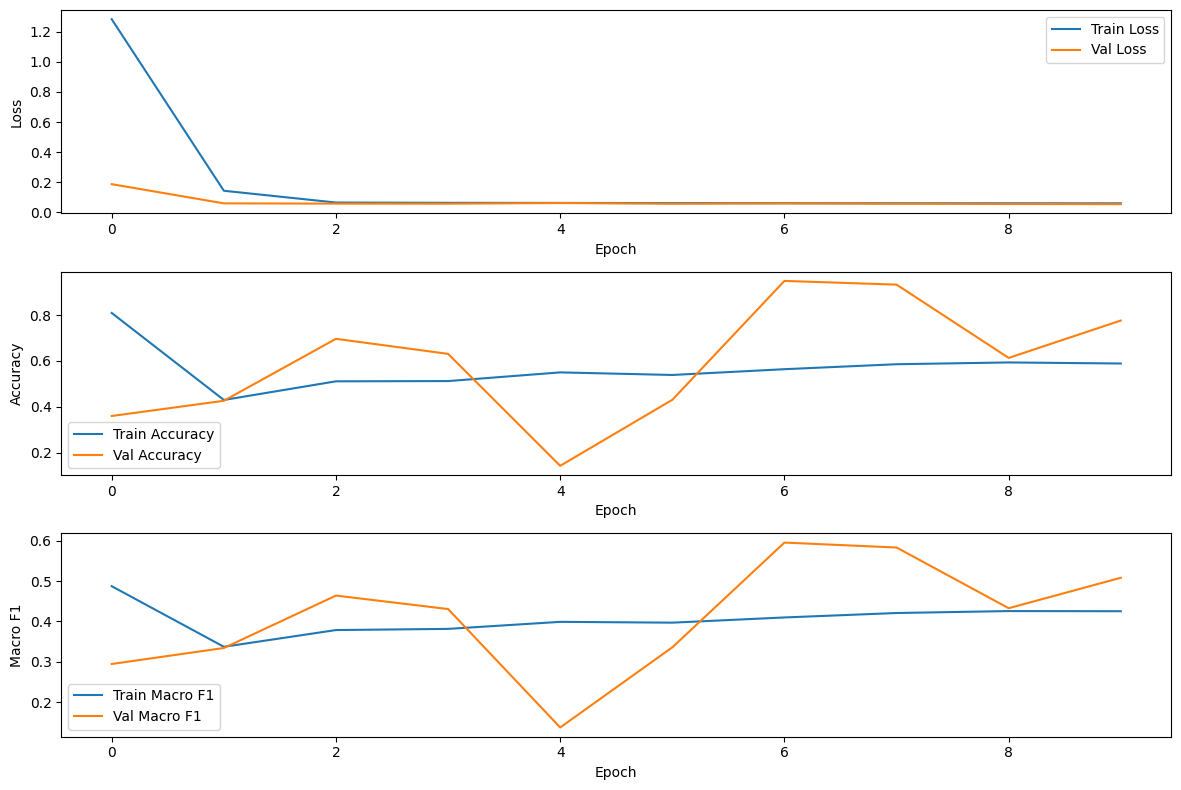

--- Train Set Classification Report ---
              precision    recall  f1-score   support

       False       0.08      0.58      0.14       591
        True       0.97      0.68      0.80     12541

    accuracy                           0.67     13132
   macro avg       0.52      0.63      0.47     13132
weighted avg       0.93      0.67      0.77     13132

--- Validation Set Classification Report ---
              precision    recall  f1-score   support

       False       0.09      0.48      0.15        56
        True       0.97      0.79      0.87      1360

    accuracy                           0.78      1416
   macro avg       0.53      0.64      0.51      1416
weighted avg       0.94      0.78      0.84      1416

--- Test Set Classification Report ---
              precision    recall  f1-score   support

       False       0.16      0.63      0.25       240
        True       0.95      0.67      0.79      2501

    accuracy                           0.67      2741
   m

In [20]:
torch.manual_seed(2022)  # For reproducibility

pos_samples = y_train.sum().item()
neg_samples = len(y_train) - pos_samples
pos_weight = torch.tensor([neg_samples / pos_samples])

model = CombinedModel(embedding_matrix, X_train_encoded.shape[1], 128, 1)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s = Trainer.train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=10
)

# Plot training and validation metrics
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s)

# Evaluate on train, validation, and test sets
train_true_labels, train_predicted_labels = Trainer.evaluate_model(model, train_loader)
val_true_labels, val_predicted_labels = Trainer.evaluate_model(model, val_loader)
test_true_labels, test_predicted_labels = Trainer.evaluate_model(model, test_loader)

print("--- Train Set Classification Report ---")
print(classification_report(train_true_labels, train_predicted_labels, target_names=['False', 'True']))
print("--- Validation Set Classification Report ---")
print(classification_report(val_true_labels, val_predicted_labels, target_names=['False', 'True']))

print("--- Test Set Classification Report ---")
print(classification_report(test_true_labels, test_predicted_labels, target_names=['False', 'True']))


In [18]:
torch.save(model.state_dict(), 'combined_model_weights.pth')
print("Model saved to combined_model_weights.pth")

Model saved to combined_model_weights.pth


In [19]:
# === Reload and evaluate saved model ===
model = CombinedModel(embedding_matrix, X_train_encoded.shape[1], 128, 1)
model.load_state_dict(torch.load('combined_model_weights.pth'))
model.eval()

# Evaluate on test set
test_true_labels, test_predicted_labels = Trainer.evaluate_model(model, test_loader)

print("--- Reloaded Model: Test Set Classification Report ---")
print(classification_report(test_true_labels, test_predicted_labels, target_names=['False', 'True']))


--- Reloaded Model: Test Set Classification Report ---
              precision    recall  f1-score   support

       False       0.11      0.88      0.19       240
        True       0.96      0.30      0.46      2501

    accuracy                           0.35      2741
   macro avg       0.54      0.59      0.33      2741
weighted avg       0.89      0.35      0.44      2741

